# 02 — Signal exploration

Visual and quantitative patterns in the curated **base dataset** that inform feature design and modeling.

Prerequisites: `python scripts/download_usda_data.py` and notebook `01_data_exploration.ipynb` (modeling audit).


## Setup

- **`raw_dataset`**: full USDA API snapshot (reporting grain, includes commodity/region duplicates).
- **`base_dataset`**: lane-week panel from `build_lane_week_panel()` — the population intended for modeling and scoring (`date + origin + destination`, `rpm = mean`).


In [7]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from freight_rates.ingestion import load_raw_snapshot
from freight_rates.preprocessing import build_lane_week_panel

ROOT = Path("..").resolve()
raw_dataset = load_raw_snapshot(raw_dir=ROOT / "data" / "raw")
base_dataset = build_lane_week_panel(raw_dataset)
base_dataset["month"] = pd.to_numeric(base_dataset["month"], errors="coerce").astype("Int64")

print(f"lane-week rows: {len(base_dataset):,}")
print(f"date range: {base_dataset['date'].min().date()} → {base_dataset['date'].max().date()}")
print(f"lanes: {base_dataset['lane_id'].nunique():,} | destinations: {base_dataset['destination'].nunique()}")


lane-week rows: 193,487
date range: 2000-01-04 → 2026-08-18
lanes: 792 | destinations: 10


## 1. Weekly RPM time series

Median RPM each week (global and by destination). Volume overlay shows reporting intensity.


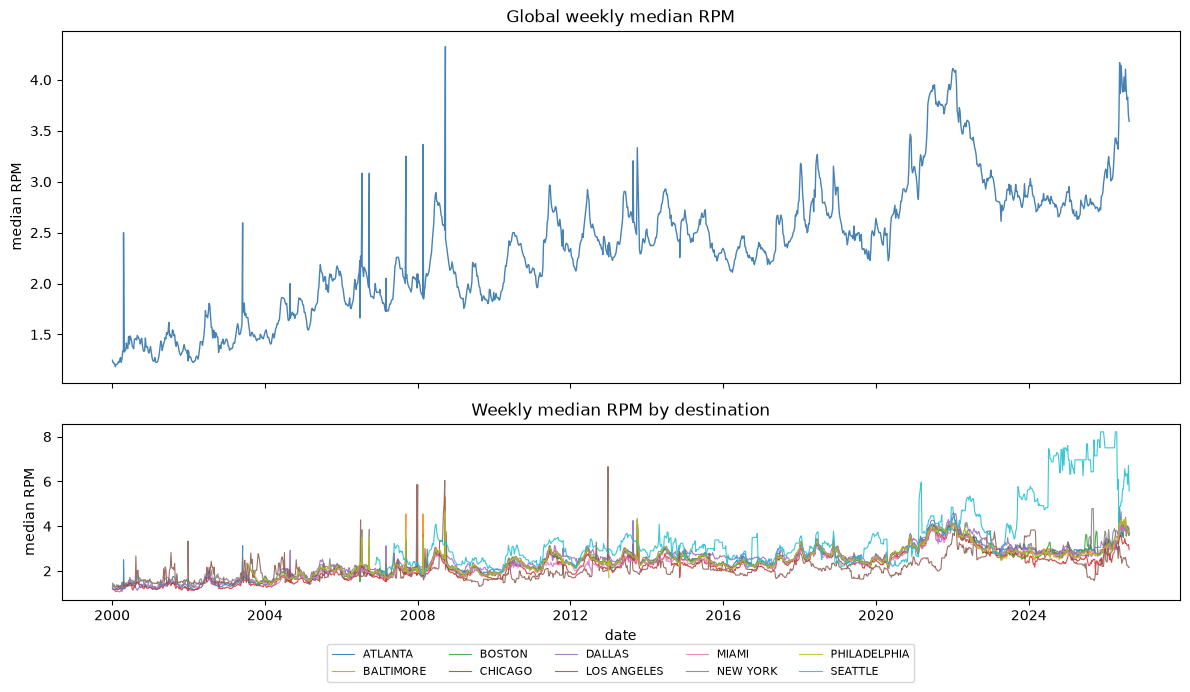

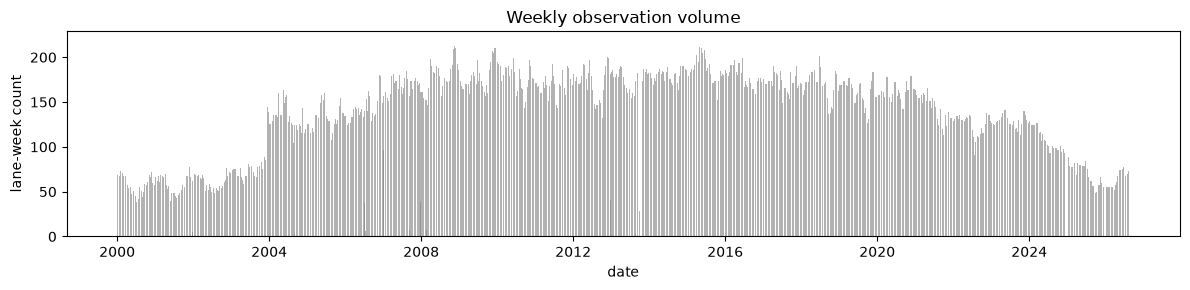

,count,mean,std,min,25%,50%,75%,max
median_rpm,1406.0,2.348021,0.625369,1.184211,1.885585,2.371006,2.75,4.326923


In [8]:
weekly_global = (
    base_dataset.groupby("date", as_index=False)
    .agg(median_rpm=("rpm", "median"), n_obs=("rpm", "count"))
    .sort_values("date")
)

weekly_dest = (
    base_dataset.groupby(["date", "destination"], as_index=False)
    .agg(median_rpm=("rpm", "median"))
    .sort_values(["destination", "date"])
)

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True, height_ratios=[2, 1])
axes[0].plot(weekly_global["date"], weekly_global["median_rpm"], color="steelblue", lw=1)
axes[0].set_ylabel("median RPM")
axes[0].set_title("Global weekly median RPM")

for dest, grp in weekly_dest.groupby("destination"):
    axes[1].plot(grp["date"], grp["median_rpm"], lw=0.8, alpha=0.85, label=dest)
axes[1].set_ylabel("median RPM")
axes[1].set_xlabel("date")
axes[1].set_title("Weekly median RPM by destination")
axes[1].legend(loc="upper center", bbox_to_anchor=(0.5, -0.22), ncol=5, fontsize=8)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 3))
ax.bar(weekly_global["date"], weekly_global["n_obs"], width=5, color="gray", alpha=0.6)
ax.set_ylabel("lane-week count")
ax.set_xlabel("date")
ax.set_title("Weekly observation volume")
plt.tight_layout()
plt.show()

weekly_global[["median_rpm"]].describe().T


**Takeaway:** RPM moves with clear multi-year cycles and destination-specific levels. Observation volume is uneven over time — recent years have fewer active weeks/lanes.

That decline is mostly **reporting coverage**, not a collapse in produce trucking. FVWTRK only quotes open (spot) rates when a district is actively shipping and brokers/shippers report; AMS also dropped California→LA short-haul (0–500 mi) rates from 2025 Q1. Treat 2025–26 as partial years when comparing annual totals.


## 2. Origin × destination heatmaps

Top 20 origins by volume. Color = median RPM or observation count.


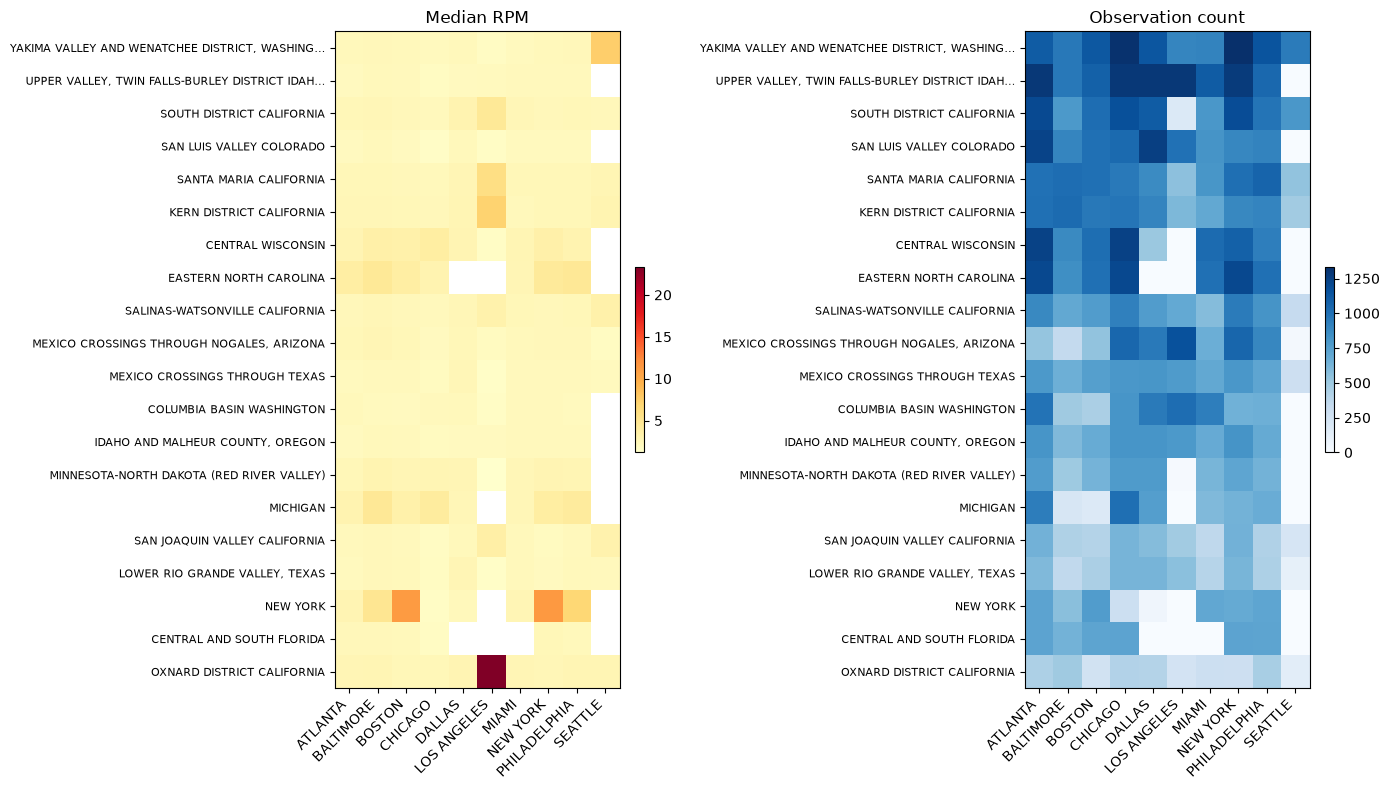

In [9]:
TOP_N = 20
metric_cols = ["rpm", "lane_id"]

top_origins = base_dataset["origin"].value_counts().head(TOP_N).index
destinations = sorted(base_dataset["destination"].unique())
subset = base_dataset[base_dataset["origin"].isin(top_origins)]

rpm_pivot = (
    subset.groupby(["origin", "destination"])["rpm"]
    .median()
    .unstack("destination")
    .reindex(index=top_origins, columns=destinations)
)
count_pivot = (
    subset.groupby(["origin", "destination"])["lane_id"]
    .count()
    .unstack("destination")
    .reindex(index=top_origins, columns=destinations)
    .fillna(0)
)

short_labels = [o[:45] + ("…" if len(o) > 45 else "") for o in top_origins]

fig, axes = plt.subplots(1, 2, figsize=(14, 8))
for ax, data, title, cmap in [
    (axes[0], rpm_pivot, "Median RPM", "YlOrRd"),
    (axes[1], count_pivot, "Observation count", "Blues"),
]:
    im = ax.imshow(data.values, aspect="auto", cmap=cmap)
    ax.set_xticks(range(len(destinations)))
    ax.set_xticklabels(destinations, rotation=45, ha="right")
    ax.set_yticks(range(len(top_origins)))
    ax.set_yticklabels(short_labels, fontsize=8)
    ax.set_title(title)
    plt.colorbar(im, ax=ax, fraction=0.03)
plt.tight_layout()
plt.show()


**Takeaway:** Rate levels and data density vary sharply across OD pairs. Sparse cells (light count heatmap) align with cold-start lanes.


## 3. Seasonality and autocorrelation

Monthly RPM distribution and ACF of the global weekly median series (52-week max lag).


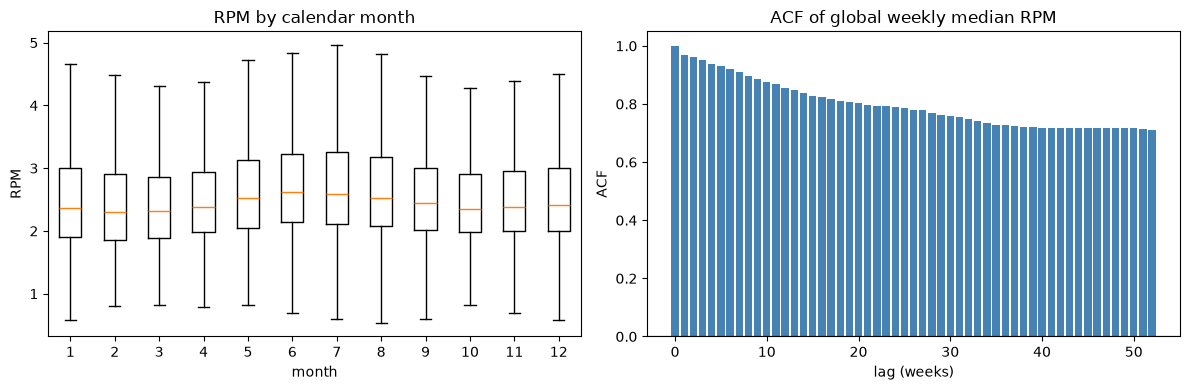

,count,median,mean
month,,,
1,16555,2.365079,2.734514
2,15068,2.307692,2.642871
3,17032,2.321429,2.630930
4,16642,2.379310,2.701003
5,17009,2.517857,2.816786
6,16475,2.626263,2.944053
7,15786,2.591751,2.964194
8,15470,2.519231,2.902702
9,14486,2.446429,2.816738


In [10]:
# Same idea as statsmodels.tsa.stattools.acf
def acf(x: pd.Series, nlags: int = 52) -> pd.Series:
    s = x.dropna().astype(float)
    if len(s) < 2:
        return pd.Series(dtype=float)
    s = s - s.mean()
    denom = (s**2).sum()
    values = {0: 1.0}
    for lag in range(1, min(nlags, len(s) - 1) + 1):
        values[lag] = (s.iloc[:-lag].to_numpy() * s.iloc[lag:].to_numpy()).sum() / denom
    return pd.Series(values)


monthly = base_dataset.copy()
monthly["month"] = monthly["month"].astype(int)
monthly_box = [monthly.loc[monthly["month"] == m, "rpm"].dropna().values for m in range(1, 13)]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].boxplot(monthly_box, tick_labels=list(range(1, 13)), showfliers=False)
axes[0].set_xlabel("month")
axes[0].set_ylabel("RPM")
axes[0].set_title("RPM by calendar month")

acf_vals = acf(weekly_global.set_index("date")["median_rpm"], nlags=52)
axes[1].bar(acf_vals.index, acf_vals.values, color="steelblue", width=0.8)
axes[1].axhline(0, color="black", lw=0.8)
axes[1].set_xlabel("lag (weeks)")
axes[1].set_ylabel("ACF")
axes[1].set_title("ACF of global weekly median RPM")
plt.tight_layout()
plt.show()

base_dataset.groupby("month")["rpm"].agg(["count", "median", "mean"]).astype({"median": float, "mean": float})


**Takeaway:** Summer months tend to show higher RPM dispersion...more competition for reefers?; weekly RPM is autocorrelated, supporting lag features (`rpm_lag_1`, rolling means).


## 4. Availability vs RPM

Relationship between truck availability and rate per mile.


Pearson(availability, rpm):  0.0755
Spearman(availability, rpm): 0.1389


,count,median,mean
availability,,,
1,11286,2.067805,2.173844
2,13543,2.153846,2.303484
3,117683,2.478704,2.879326
4,29345,2.476190,2.808637
5,21630,2.566391,2.815356


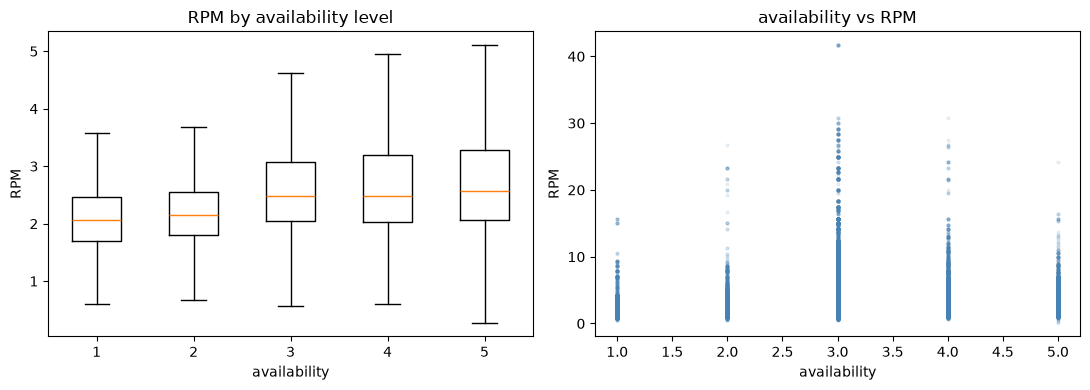

In [11]:
avail = base_dataset.dropna(subset=["availability", "rpm"]).copy()
avail["availability"] = avail["availability"].round().astype(int)

pearson = avail["availability"].corr(avail["rpm"], method="pearson")
spearman = avail["availability"].corr(avail["rpm"], method="spearman")
print(f"Pearson(availability, rpm):  {pearson:.4f}")
print(f"Spearman(availability, rpm): {spearman:.4f}")

by_avail = (
    avail.groupby("availability")["rpm"]
    .agg(count="count", median="median", mean="mean")
    .sort_index()
)
display(by_avail)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].boxplot(
    [avail.loc[avail["availability"] == a, "rpm"] for a in sorted(avail["availability"].unique())],
    tick_labels=sorted(avail["availability"].unique()),
    showfliers=False,
)
axes[0].set_xlabel("availability")
axes[0].set_ylabel("RPM")
axes[0].set_title("RPM by availability level")

axes[1].scatter(avail["availability"], avail["rpm"], s=4, alpha=0.1, color="steelblue")
axes[1].set_xlabel("availability")
axes[1].set_ylabel("RPM")
axes[1].set_title("availability vs RPM")
plt.tight_layout()
plt.show()


**Takeaway:* Makes sense that Availability = 5 (shortage) is associeted with higher RPM. 


## 5. Example lane series

Ten highest-volume lanes — weekly RPM over the full history.


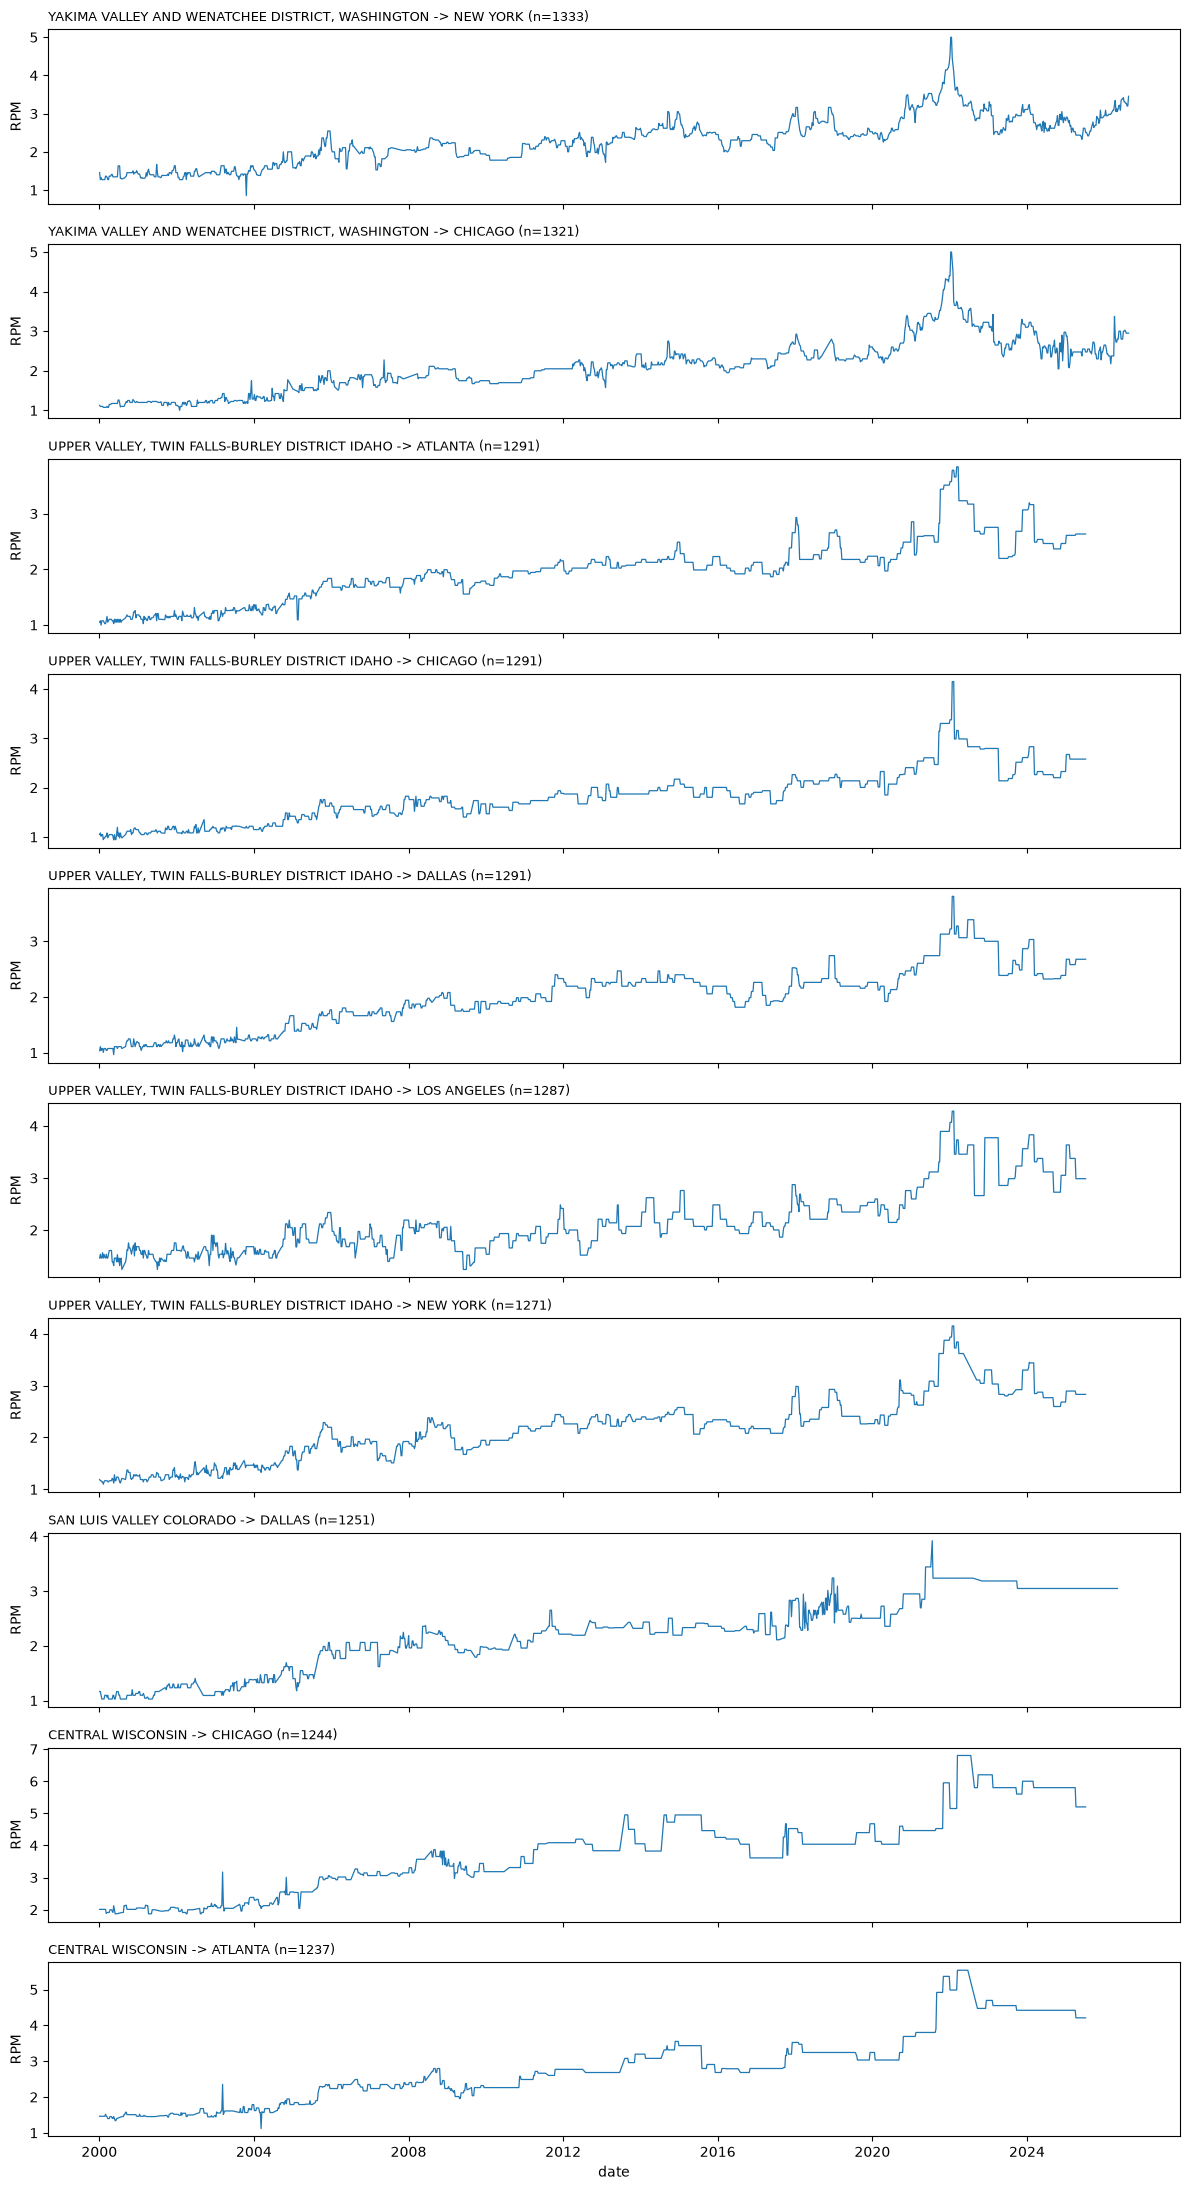

,count,median,std
lane_id,,,
"YAKIMA VALLEY AND WENATCHEE DISTRICT, WASHINGTON -> NEW YORK",1333,2.309091,0.597012
"YAKIMA VALLEY AND WENATCHEE DISTRICT, WASHINGTON -> CHICAGO",1321,2.100000,0.648753
"UPPER VALLEY, TWIN FALLS-BURLEY DISTRICT IDAHO -> ATLANTA",1291,2.021463,0.539659
"UPPER VALLEY, TWIN FALLS-BURLEY DISTRICT IDAHO -> CHICAGO",1291,1.804403,0.512345
"UPPER VALLEY, TWIN FALLS-BURLEY DISTRICT IDAHO -> DALLAS",1291,2.056774,0.538595
"UPPER VALLEY, TWIN FALLS-BURLEY DISTRICT IDAHO -> LOS ANGELES",1287,2.070130,0.617823
"UPPER VALLEY, TWIN FALLS-BURLEY DISTRICT IDAHO -> NEW YORK",1271,2.215532,0.588721
SAN LUIS VALLEY COLORADO -> DALLAS,1251,2.272603,0.644791
CENTRAL WISCONSIN -> CHICAGO,1244,3.836000,1.206787


In [12]:
EXAMPLE_LANES = 10
example_ids = base_dataset["lane_id"].value_counts().head(EXAMPLE_LANES).index
example = base_dataset[base_dataset["lane_id"].isin(example_ids)].copy()

fig, axes = plt.subplots(EXAMPLE_LANES, 1, figsize=(12, 2.2 * EXAMPLE_LANES), sharex=True)
if EXAMPLE_LANES == 1:
    axes = [axes]

for ax, lane_id, grp in zip(axes, example_ids, [example[example["lane_id"] == lid] for lid in example_ids]):
    grp = grp.sort_values("date")
    ax.plot(grp["date"], grp["rpm"], lw=0.9)
    ax.set_ylabel("RPM")
    ax.set_title(f"{lane_id} (n={len(grp)})", fontsize=9, loc="left")
axes[-1].set_xlabel("date")
plt.tight_layout()
plt.show()

example.groupby("lane_id")["rpm"].agg(["count", "median", "std"]).sort_values("count", ascending=False)


**Takeaway:** Mature lanes show persistent level differences and visible seasonality; individual lane noise confirms the need for pooling or hierarchical models on sparse lanes.


## Summary — modeling implications

| Finding | Implication |
|---|---|
| Weekly RPM trends + seasonality | Calendar features and lagged RPM are justified |
| OD heatmap heterogeneity | Global model + lane/OD encodings; watch sparse cells |
| Positive weekly ACF | Use `rpm_lag_1` and rolling history features |
| Weak availability signal | Include availability, but do not rely on it alone |
| Lane-level series vary widely | Hierarchical / partial-pooling approach for cold start |

**Next step:** define temporal train/validation splits and cold-start holdouts before fitting models.
